In [1]:
import pandas as pd
import numpy as np

import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import jarque_bera, chi2
import scipy as sc

np.random.seed(1)

In [2]:
tickers = ['SPY', 'QQQ', 'TLT', 'GLD']
start = '2015-01-01'
end = '2026-03-31'

In [3]:
prices = yf.download(tickers, start, end, auto_adjust=True)['Close']

[*********************100%***********************]  4 of 4 completed


In [4]:
prices.isna().sum()

Ticker
GLD    0
QQQ    0
SPY    0
TLT    0
dtype: int64

In [5]:
df = prices.pct_change().dropna()

<h1>Train-Test-Split</h1>

Splitting Data in 80% Training and 20% Testing

In [6]:
threshold = int(len(df) * 0.80)

In [7]:
df_train = df.iloc[:threshold]

In [8]:
df_test = df.iloc[threshold:]

In [9]:
print(f'The training dataset has {df_train.shape[0]} observations and {df_train.shape[1]} columns.')
print(f'The first day of training dataset is {df_train.index[0]}')
print(f'The training dataset has {df_test.shape[0]} observations and {df_test.shape[1]} columns.')
print(f'The first day of training dataset is {df_test.index[0]}')

The training dataset has 2260 observations and 4 columns.
The first day of training dataset is 2015-01-05 00:00:00
The training dataset has 565 observations and 4 columns.
The first day of training dataset is 2023-12-27 00:00:00


<h1>Exploration</h1>

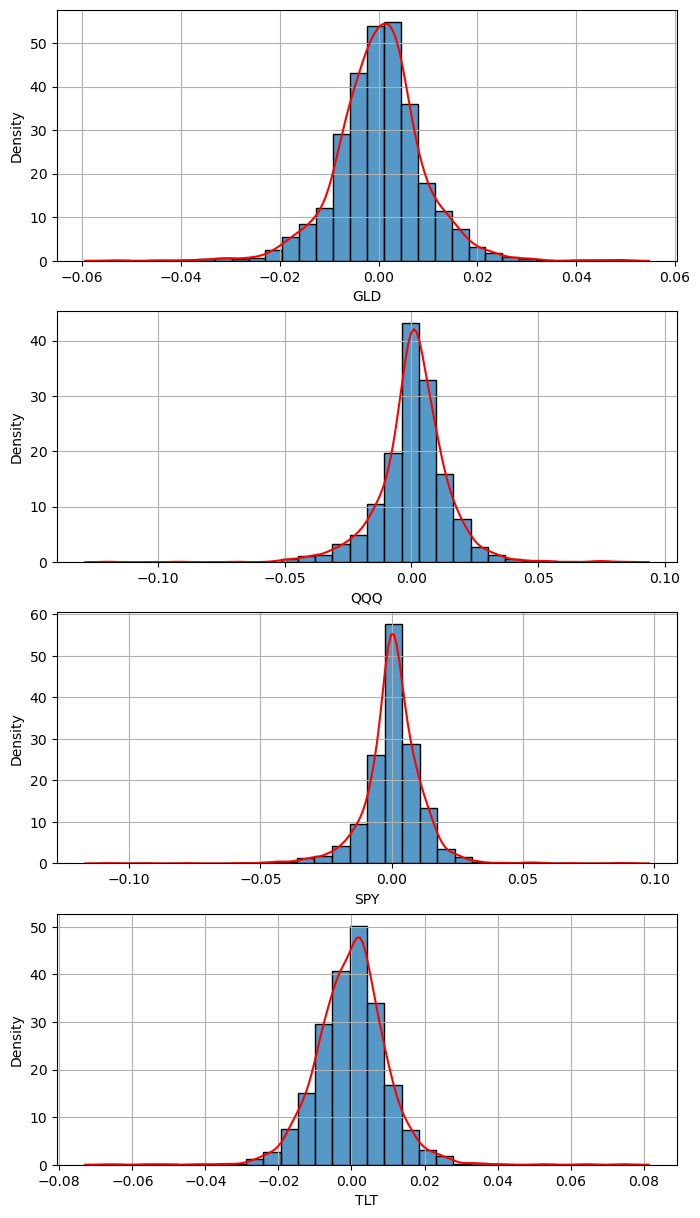

In [10]:
fig, ax = plt.subplots(df_train.shape[1], figsize=(8,15))

for col, ax in zip(df_train.columns, ax):
    sns.histplot(df_train, x=col, stat='density', bins=30, ax=ax)
    sns.kdeplot(df_train, x=col, color='red', ax=ax)
    ax.grid(True)

In [11]:
for col in df_train.columns:
    jb_stats, jb_p_value = jarque_bera(df_train[col])
    print(f'Test Statistics for {col} is {jb_stats:.4f}.')
    print(f'The p-value for {col} is {jb_p_value:.4f}.')
    if jb_p_value < 0.05:
        print(f'Reject the Null Hypothesis. The return of {col} is NOT normally distributed.')
    else:
        print(f'Fail to Reject the Null Hypothesis. The return of {col} is Normally distributed.')
    print(f'==========================================================================')

Test Statistics for GLD is 851.3109.
The p-value for GLD is 0.0000.
Reject the Null Hypothesis. The return of GLD is NOT normally distributed.
Test Statistics for QQQ is 3915.2325.
The p-value for QQQ is 0.0000.
Reject the Null Hypothesis. The return of QQQ is NOT normally distributed.
Test Statistics for SPY is 14973.1825.
The p-value for SPY is 0.0000.
Reject the Null Hypothesis. The return of SPY is NOT normally distributed.
Test Statistics for TLT is 2209.7199.
The p-value for TLT is 0.0000.
Reject the Null Hypothesis. The return of TLT is NOT normally distributed.


<h1>Parametric (Variance-Covariance) VaR Method</h1>

In [12]:
T, N = df_train.shape[0], df_train.shape[1]

In [13]:
portfolio_value = 100000                               # Vo
portfolio_weights = np.array([1/N] * N)                # Equal-weighted portfolio
portfolio_return = df_train @ portfolio_weights
alpha = 0.95                                           # 95% confidence

In [14]:
z_alpha = sc.stats.norm.ppf(alpha)

In [15]:
cov_alpha = df_train.cov()

$$\sigma_p = \sqrt{w\Sigma w^T}$$

In [16]:
sigma_p = np.sqrt(portfolio_weights @ cov_alpha.values @ portfolio_weights)

Parametric VaR formula:
$$VaR_{\alpha} = V_0 . z_{\alpha} . \sigma - \mu_p$$

As daily $\mu$ is small, so practitioner offen ignore it. I'm ignoring it as well.

updated VaR formula:
$$VaR_{\alpha} = V_0 . z_{\alpha} . \sigma$$

In [17]:
var_alpha = portfolio_value * z_alpha * sigma_p

Parametric CVaR formula:
$$CVaR_{\alpha} = V_0 \left(\frac{\phi(z_{\alpha})}{1 - alpha}\sigma - \mu_p \right)$$

Ignoring $\mu$ for CVaR as well.

The formula will become:
$$CVaR_{\alpha} = V_0 \left(\frac{\phi(z_{\alpha})}{1 - alpha}\sigma \right)$$

In [18]:
cvar_alpha = portfolio_value * (((sc.stats.norm.pdf(z_alpha)) / (1 - alpha)) * sigma_p)

In [19]:
print(f'The Parametric VaR is ${var_alpha:.4f} and CVaR is ${cvar_alpha:.4f}.')

The Parametric VaR is $1142.5959 and CVaR is $1432.8614.


<h1>Monte-Carlo Simulation VaR Method</h1>

In [20]:
mu = df_train.mean().values

In [21]:
sigma_mc = df_train.cov().values

In [22]:
L = np.linalg.cholesky(sigma_mc)

In [23]:
n_simulation = 100000

In [24]:
standardized = (df_train - df_train.mean()) / df_train.std(ddof=1)

In [25]:
pooled_resituals = standardized.to_numpy().ravel()

In [26]:
nu, _, _ = sc.stats.t.fit(pooled_resituals)

In [27]:
z_mc = np.random.standard_normal((n_simulation, N))

In [28]:
X = z_mc @ L.T

In [29]:
w = chi2.rvs(df=nu, size=n_simulation)

variance adjustment = $\sqrt{\nu - 2 / \nu}$

In [30]:
variance_adjustment = np.sqrt((nu - 2) / nu)

scaling factor = $\sqrt{\nu/w}$

In [31]:
scale = variance_adjustment * np.sqrt(nu/w)

In [32]:
X *= scale[:, None]

In [33]:
simulated_return = mu + X

In [34]:
portfolio_return_mc = simulated_return @ portfolio_weights

In [35]:
losses_mc = -portfolio_return_mc

In [36]:
var_mc = np.quantile(losses_mc, alpha)

In [37]:
cvar_mc = losses_mc[losses_mc >= var_mc].mean()

In [38]:
print(f'The Monte-Carlo Simulated VaR is ${var_mc*portfolio_value:.4f} and CVaR is ${cvar_mc*portfolio_value:.4f}')

The Monte-Carlo Simulated VaR is $980.6497 and CVaR is $1532.0076


<h1>Cornish-Fisher VaR </h1>

In [39]:
portfolio_return_cf = portfolio_return

In [40]:
S = sc.stats.skew(portfolio_return_cf)

In [41]:
K = sc.stats.kurtosis(portfolio_return_cf)

The formula for `cornish-fisher quantile` is:

$$z_{CF} = z_{\alpha} + \frac{(z_{\alpha}^2 - 1)}{6} S + \frac{(z_{\alpha}^3 - 3z_{\alpha})}{24} K - \frac{(2z_{\alpha}^3 - 5z_{\alpha})}{36} S^2$$

In [42]:
z_cf = z_alpha + ((z_alpha**2 - 1) / 6)*S + ((z_alpha**3 - 3*z_alpha) / 24)*K - ((2*z_alpha**3 - 5*z_alpha) / 36)*S**2

$$VaR_{CF} = V_0 . \sigma . z_{CF}$$

Ignoring $\mu$ as its very less for daily returns.

In [43]:
sigma_cf = np.sqrt(portfolio_weights @ df_train.cov().values @ portfolio_weights)

In [44]:
var_cf = portfolio_value * sigma_cf * z_cf

In [45]:
losses_cf = -portfolio_return_cf * portfolio_value

In [46]:
cvar_cf = losses_cf[losses_cf >= var_cf].mean()

In [47]:
print(f'The Cornish_Fisher VaR is ${var_cf:.4f} and CVaR is ${cvar_cf:.4f}')

The Cornish_Fisher VaR is $986.5107 and CVaR is $1560.2352


Cornish-Fisher VaR was computed using the Cornish-Fisher adjusted quantile. Since the Cornish-Fisher expansion does not provide a simple closed-form expression for Expected Shortfall, CVaR was estimated empirically as the average of historical losses exceeding the Cornish-Fisher VaR threshold.

<h1>Extreme Value Theory (EVT) Method</h1>

EVT throws away the boring middle part of the distribution and *fits* only the extreme losses.<br>
I'm implementing `Peak-Over_Threshold (POT)` approach. In POT we fit **Generalized Pareto Distribution (GPD)** to all data points.

In [48]:
portfolio_return_evt = portfolio_return

In [49]:
losses_evt = -portfolio_return_evt

In [50]:
losses_evt

Date
2015-01-05    0.000486
2015-01-06   -0.001647
2015-01-07   -0.004371
2015-01-08   -0.004858
2015-01-09   -0.001935
                ...   
2023-12-19   -0.005848
2023-12-20    0.006847
2023-12-21   -0.005465
2023-12-22   -0.000848
2023-12-26   -0.005202
Length: 2260, dtype: float64

The EVT VaR formula:
$$VaR_{\alpha} = u + \frac{\beta}{\xi} \left[\left(\frac{N}{N_u}(1-\alpha)\right)^{-\xi}-1\right]$$

where:<br>
$u$ = threshold<br>
$\beta$ = scale parameter<br>
$\xi$ = shape parameter<br>
$N$ = number of observations<br>
$N_u$ = number of excessess

I'm selecting the threshold at *95 percentile*.

In [51]:
u = losses_evt.quantile(0.95)
u

np.float64(0.010828776519653084)

In [52]:
N = len(losses_evt)
N

2260

excesses are:
$$Y = L - u,  \ \ \ L > u$$

In [53]:
excesses = losses_evt[losses_evt > u] - u

In [54]:
Nu = len(excesses)
Nu

113

Fitting GPD only on excesses because I want to model tail values, the extreme ones. 

In [55]:
shape, loc, scale = sc.stats.genpareto.fit(excesses, floc=0)

In [56]:
beta = scale

In [57]:
# using VaR formula of POT
var_evt = u + (beta / shape) * (((N / Nu) * (1 - alpha))**-shape - 1)

In [58]:
var_evt

np.float64(0.01082877651965308)

CVaR formula of POT:
$$CVaR_{\alpha} = \frac{VaR_{\alpha} + \beta - \xi u}{1-\xi}$$

In [59]:
cvar_evt = (var_evt + beta - shape*u) / (1 - shape)

In [60]:
cvar_evt

np.float64(0.016415183321241242)

In [61]:
print(f'The EVT Peak-Over-Threshold VaR is ${var_evt*portfolio_value:.4f} and CVaR is ${cvar_evt*portfolio_value:.4f}.')

The EVT Peak-Over-Threshold VaR is $1082.8777 and CVaR is $1641.5183.


<h1>Historical Simulation VaR Method</h1>

In [62]:
T, N = df_train.shape[0], df_train.shape[1]

In [63]:
train_losses = -portfolio_return

In [64]:
var = np.quantile(train_losses, alpha)

In [65]:
cvar = train_losses[train_losses >= var].mean()

In [66]:
print(
    f'The Historical Simulated VaR is ${var*portfolio_value:.4f} and CVaR is ${cvar*portfolio_value:.4f}.'
)

The Historical Simulated VaR is $1082.8777 and CVaR is $1639.5094.


<h2>Backtesting</h2>

For backtesting, I'm using `Walk-Forward validation` method on the test set, with the window of 252. 

In [67]:
portfolio_return = df_test @ portfolio_weights

In [68]:
test_losses = -portfolio_return

In [69]:
window = 252        # last 1 year data

In [70]:
rolling_history = train_losses.iloc[-window:].copy()

In [71]:
predicted_var = []
actual_losses = []
violations = []

In [72]:
for loss in test_losses:
    var = rolling_history.quantile(alpha)

    predicted_var.append(var)

    actual_losses.append(loss)

    violations.append(loss > var)

    rolling_history = pd.concat([rolling_history.iloc[1:], pd.Series([loss])], ignore_index=True)

In [73]:
backtest = pd.DataFrame(
    {
        'Actual Loss': actual_losses,
        'Predicted VaR': predicted_var,
        'Violations': violations,
    },
    index = test_losses.index
)

In [74]:
backtest

,Actual Loss,Predicted VaR,Violations
Date,,,
2023-12-27,-0.006525,0.010149,False
2023-12-28,0.003297,0.010149,False
2023-12-29,0.004452,0.010149,False
2024-01-02,0.007659,0.010149,False
2024-01-03,0.005729,0.010149,False
...,...,...,...
2026-03-24,0.003592,0.011942,False
2026-03-25,-0.012972,0.011942,False
2026-03-26,0.021932,0.011942,True


In [75]:
n_predictions = len(backtest)

In [76]:
n_violations = backtest.Violations.sum()

In [77]:
violation_rate = n_violations / n_predictions

In [78]:
print(f'Number of forecasts: {n_predictions}.')
print(f'Number of Violations: {n_violations}.')
print(f'Violation Rate: {violation_rate}.')

Number of forecasts: 565.
Number of Violations: 33.
Violation Rate: 0.0584070796460177.


<h2>The Kupiec Proportion of Failures (POF) Test</h2>

The Kupiec uses **likelihood ratio** test.
$$LR_{POF} = -2ln\left[\frac{p^x(1-p)^{T-x}}{\hat{p}^x(1-\hat{p})^{T-x}}\right]$$

For simplification, I'm rewriting the formula:

$$LR_{POF} = -2ln\left[\frac{L_0}{L_1}\right]$$

where:<br>$L_0$ is $p^x(1-p)^{T-x}$ and,<br>
$L_1$ is $\hat{p}^x(1-\hat{p})^{T-x}$

In [79]:
T = n_predictions    # Number of days I'm testing over

In [80]:
x = n_violations     # Number of breaches observed

In [81]:
p = 1 - alpha        # Expected breach rate

In [82]:
pi = x / T           # observed breach rate

In [83]:
l0 = p**x * (1-p)**(T-x)

In [84]:
l1 = pi**x * (1-pi)**(T-x)

In [85]:
LR_POF = -2 * np.log(l0/l1)

In [86]:
p_value = 1 - chi2.cdf(LR_POF, df=1)

In [87]:
if p_value < 0.05:
    print("Reject H0")
    print("The VaR model does NOT exhibit correct unconditional coverage.")
else:
    print("Fail to Reject H0")
    print("The VaR model exhibits acceptable unconditional coverage.")

Fail to Reject H0
The VaR model exhibits acceptable unconditional coverage.


<h2>The Christoffersen Independence Test</h2>

In this test, we compute two conditional probabilities:

$$\pi_{01} = \frac{n_{01}}{n_{00} + n_{01}}$$ 

$\pi_{01}$ is (chances of breach after a calm day)

$$\pi_{11} = \frac{n_{11}}{n_{10} + n_{11}}$$

$\pi_{11}$ is (chances of breach after a breach day)

In [88]:
violation_series = backtest.Violations.astype(int).values

In [89]:
n00 = 0
n01 = 0
n10 = 0
n11 = 0

In [90]:
for i in range(len(violation_series) - 1):

    today = violation_series[i]
    tomorrow = violation_series[i + 1]

    if today == 0 and tomorrow == 0:
        n00 += 1

    elif today == 0 and tomorrow == 1:
        n01 += 1

    elif today == 1 and tomorrow == 0:
        n10 += 1

    elif today == 1 and tomorrow == 1:
        n11 += 1

In [91]:
print(f"N00 = {n00}")
print(f"N01 = {n01}")
print(f"N10 = {n10}")
print(f"N11 = {n11}")

N00 = 500
N01 = 31
N10 = 31
N11 = 2


In [92]:
n00 + n01 + n10 + n11 == len(backtest)-1

True

In [93]:
#computing probabilities
pi01 = n01 / (n00 + n01)

pi11 = n11 / (n10 + n11)

In [94]:
#computing unconditional probability
pi = (n01 + n11) / (n00 + n01 + n10 + n11)

The **likelihood ratio** of `Christoffersen` is:
$$LR_{IND} = -2ln\left[\frac{\pi^{n_{01}+n_{11}}(1-\pi)^{n_{00}+n_{10}}}{(1-\pi_{01})^{n_{00}} (\pi_{01})^{n_{01}} (1-\pi_{11})^{n_{10}} (\pi_{11})^{n_{11}}}\right]$$

For simplification, I'm rewriten the formula:
$$LR_{IND} = -2ln\left[\frac{L_0}{L_1}\right]$$

where:<br>
$L_0$ = $\pi^{n_{01}+n_{11}}(1-\pi)^{n_{00}+n_{10}}$, <br>
$L_1$ = $(1-\pi_{01})^{n_{00}} (\pi_{01})^{n_{01}} (1-\pi_{11})^{n_{10}} (\pi_{11})^{n_{11}}$

In [95]:
l0 = pi**(n01 + n11) * (1 - pi)**(n00 + n10)

In [96]:
l1 = (1 - pi01)**n00 * (pi01)**n01 * (1 - pi11)**n10 * (pi11)**n11

In [97]:
LR_IND = -2 * np.log(l0 / l1)

In [98]:
p_value = 1 - chi2.cdf(LR_IND, df=1)

In [99]:
if p_value < 0.05:
    print("Reject H0")
    print("Violations are clustered.")
    print("The VaR model fails the independence test.")
else:
    print("Fail to Reject H0")
    print("Violations appear independent.")
    print("The VaR model passes the independence test.")

Fail to Reject H0
Violations appear independent.
The VaR model passes the independence test.


In [100]:
LR_CC = LR_POF + LR_IND

In [101]:
p_value = 1 - chi2.cdf(LR_CC, df=2)

In [102]:
if p_value < 0.05:
    print("Reject H0")
    print("The VaR model fails the Conditional Coverage Test.")
    print("The model does not simultaneously satisfy correct coverage and independence.")
else:
    print("Fail to Reject H0")
    print("The VaR model passes the Conditional Coverage Test.")
    print("The model exhibits acceptable coverage and independent violations.")

Fail to Reject H0
The VaR model passes the Conditional Coverage Test.
The model exhibits acceptable coverage and independent violations.


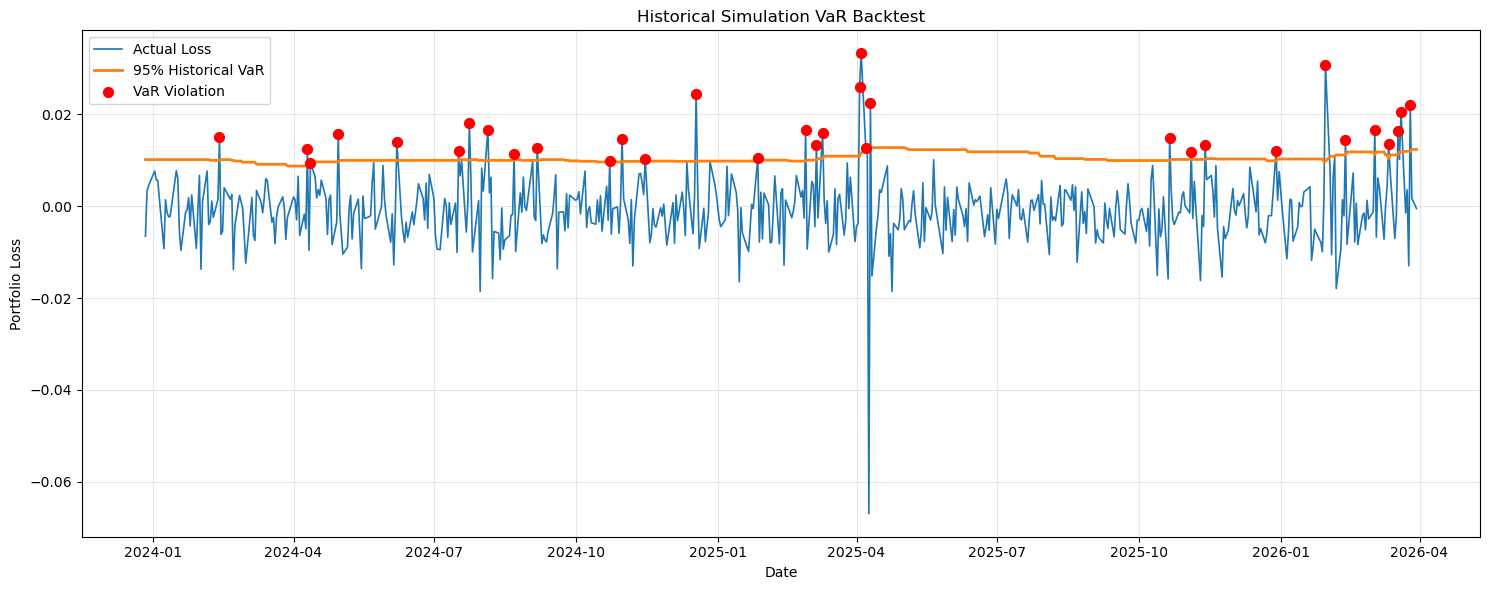

In [103]:
plt.figure(figsize=(15, 6))

# Actual portfolio losses
plt.plot(
    backtest.index,
    backtest["Actual Loss"],
    label="Actual Loss",
    linewidth=1.2
)

# Rolling Historical VaR
plt.plot(
    backtest.index,
    backtest["Predicted VaR"],
    label="95% Historical VaR",
    linewidth=2
)

# VaR violations
violations = backtest["Violations"]

plt.scatter(
    backtest.index[violations],
    backtest.loc[violations, "Actual Loss"],
    color="red",
    marker="o",
    s=50,
    label="VaR Violation",
    zorder=5
)

plt.title("Historical Simulation VaR Backtest")
plt.xlabel("Date")
plt.ylabel("Portfolio Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()